In [ ]:
import pandas as pd       # loading data
import numpy as np        # for mathematical calculations
import re                 # regular expressions for cleaning the data
import nltk               # for basics
import matplotlib.pyplot as plt # visualization
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import pandas as pd

# Create dataset
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("Customer Reviews Dataset")
print(df.head())

Customer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [ ]:

# Stopwords
stop_words = set(stopwords.words('english'))

# Function to clean text
def clean_text(text):

    # Convert to lowercase
    text = text.lower()
    print("lower case:", text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    print("special character removed:", text)

    # Tokenization
    words = word_tokenize(text)
    print("tokenization:", words)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    print("stopwords removed:", words)

    # Join words
    cleaned_text = " ".join(words)

    return cleaned_text


# Apply cleaning
df['cleaned_review'] = df['Review'].apply(clean_text)

# Print output
print("\nCleaned Review")
print(df[['Review', 'cleaned_review']])

lower case: the product quality is excellent and delivery was very fast.
special character removed: the product quality is excellent and delivery was very fast
tokenization: ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords removed: ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case: very bad packaging and the item was damaged.
special character removed: very bad packaging and the item was damaged
tokenization: ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords removed: ['bad', 'packaging', 'item', 'damaged']
lower case: customer service was helpful and responsive.
special character removed: customer service was helpful and responsive
tokenization: ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords removed: ['customer', 'service', 'helpful', 'responsive']
lower case: the delivery was delayed and support team did not respond.
special character removed: the delivery was de

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# Function for sentiment analysis
def analyze_sentiment(review):

    score = sia.polarity_scores(review)

    compound = score['compound']

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"


# Apply sentiment analysis
df['sentiment'] = df['cleaned_review'].apply(analyze_sentiment)

# Print result
print("\nSentiment Analysis Result")
print(df[['Review', 'cleaned_review', 'sentiment']])


Sentiment Analysis Result
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             cleaned_review sentiment  
0   product quality excellent delivery fast  Positive  
1                bad packaging item damaged  Negative  
2       customer service helpful responsive  Positive  
3     delivery delayed support team respond  Positive  
4               amazing product worth money  Positive  
5  poor quality prod

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
from collections import Counter

# Combine all cleaned reviews
all_words = " ".join(df['cleaned_review'])

# Convert text into list of words
word_list = all_words.split()

# Count word frequency
word_freq = Counter(word_list)

# Display top 10 keywords
print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))


Top 10 Common Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [ ]:
from collections import Counter

# Step 6: Identify Common Complaints

# Select only negative reviews
negative_reviews = df[df['sentiment'] == 'Negative']

# Combine all negative cleaned reviews
negative_words = " ".join(negative_reviews['cleaned_review'])

# Convert into word list
negative_word_list = negative_words.split()

# Count complaint keywords
complaint_freq = Counter(negative_word_list)

# Display top complaints
print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


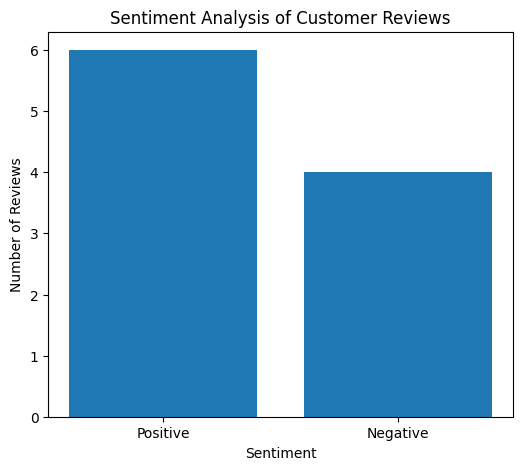

In [ ]:
import matplotlib.pyplot as plt

# Step 7: Visualization - Sentiment Count

# Count sentiments
sentiment_counts = df['sentiment'].value_counts()

# Create bar chart
plt.figure(figsize=(6,5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

# Add labels
plt.title("Sentiment Analysis of Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Show chart
plt.show()